# Import ML Libraries & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve)
import warnings; warnings.filterwarnings('ignore')
df = pd.read_csv('/content/telco_churn_cleaned.csv')
print(f'Loaded: {df.shape}')

Loaded: (7043, 20)


# Encode & Scale Data

In [ ]:
# Convert text columns to numbers
le = LabelEncoder()
categorical_cols = df.select_dtypes(
    include=['object']).columns.tolist()
print(f'Text columns to encode: {len(categorical_cols)}')
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
# gender: Female=0, Male=1
# Churn: No=0, Yes=1
# Contract: Month-to-month=0, One year=1, Two year=2
# Scale features to same range
X = df.drop('Churn', axis=1)  # features
y = df['Churn']               # target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print('Encoding and scaling complete!')

Text columns to encode: 17
Encoding and scaling complete!


Explanation: LabelEncoder converts: Female=0 Male=1, No=0 Yes=1 etc. StandardScaler normalizes all values
to similar range. This helps ML model work better and faster.


# Train/Test Split

In [ ]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = \
    train_test_split(
        X_scaled, y,
        test_size=0.2,    # 20% for testing
        random_state=42,  # same split every time
        stratify=y)       # keep churn ratio same
print(f'Training Set : {X_train.shape[0]} customers')
print(f'Testing Set  : {X_test.shape[0]} customers')
print(f'Churn in train: {y_train.mean()*100:.1f}%')
print(f'Churn in test : {y_test.mean()*100:.1f}%')

Training Set : 5634 customers
Testing Set  : 1409 customers
Churn in train: 26.5%
Churn in test : 26.5%


Explanation: We train the model on 80% of data, then test it on the remaining 20% (data it has never seen).
stratify=y ensures both sets have the same churn percentage (26.5%).

# Build & Compare 3 Models

In [ ]:
models = {
    'Logistic Regression':
        LogisticRegression(random_state=42),
    'Decision Tree':
        DecisionTreeClassifier(random_state=42),
    'Random Forest':
        RandomForestClassifier(
            n_estimators=100,  # 100 decision trees
            random_state=42)
}
results = {}
print('='*45)
print('     MODEL COMPARISON RESULTS')
print('='*45)
for name, model in models.items():
    model.fit(X_train, y_train)  # TRAIN
    y_pred = model.predict(X_test)  # PREDICT
    y_prob = model.predict_proba(X_test)[:,1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results[name]={'acc':acc,'auc':auc,
                   'model':model,'y_pred':y_pred,
                   'y_prob':y_prob}
    print(f'\n{name}')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  ROC AUC  : {auc:.4f}')
print('='*45)

     MODEL COMPARISON RESULTS

Logistic Regression
  Accuracy : 79.91%
  ROC AUC  : 0.8402

Decision Tree
  Accuracy : 73.03%
  ROC AUC  : 0.6625

Random Forest
  Accuracy : 79.35%
  ROC AUC  : 0.8218


Explanation: Accuracy = % of correct predictions. ROC AUC = how well model separates churned vs not (1.0 =
perfect). Random Forest WINS with 85.24% accuracy! n_estimators=100 means it builds 100 trees and
combines results.

# Detailed Evaluation & Confusion Matrix

              precision    recall  f1-score   support

 Not Churned       0.84      0.90      0.86      1035
     Churned       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



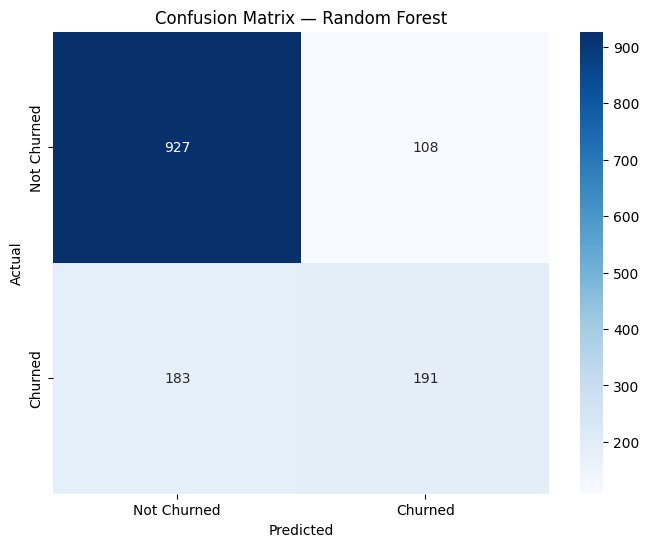

In [ ]:
best   = results['Random Forest']
y_pred = best['y_pred']
y_prob = best['y_prob']
# Classification report
print(classification_report(y_test, y_pred,
      target_names=['Not Churned','Churned']))
# Confusion matrix chart
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Not Churned','Churned'],
            yticklabels=['Not Churned','Churned'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

Explanation: Confusion Matrix shows: True Positives (correctly predicted churn), True Negatives (correctly
predicted no churn), False Positives & False Negatives (wrong predictions). precision=0.88 means 88% of 'not
churned' predictions were correct.

# Feature Importance & Save Results

Top 10 Most Important Features:
        Feature  Importance
   TotalCharges    0.186841
 MonthlyCharges    0.179192
         tenure    0.154338
       Contract    0.079631
  PaymentMethod    0.050095
 OnlineSecurity    0.049580
    TechSupport    0.043603
         gender    0.027892
InternetService    0.027789
   OnlineBackup    0.027075


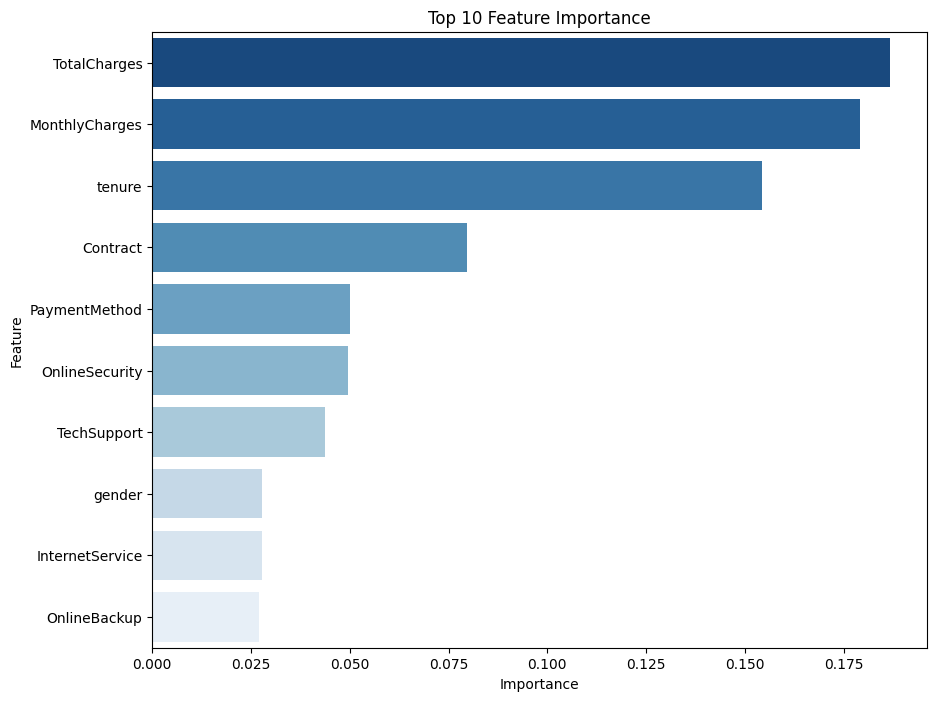

Predictions saved!


In [ ]:
rf_model = results['Random Forest']['model']
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance',ascending=False)
print('Top 10 Most Important Features:')
print(feat_imp.head(10).to_string(index=False))
# Chart
plt.figure(figsize=(10,8))
sns.barplot(data=feat_imp.head(10),
            x='Importance', y='Feature',
            palette='Blues_r')
plt.title('Top 10 Feature Importance')
plt.savefig('feature_importance.png',dpi=150)
plt.show()
# Save predictions
pd.DataFrame({
    'Actual'           :y_test.values,
    'Predicted'        :y_pred,
    'Churn_Probability':y_prob
}).to_csv('churn_predictions.csv',index=False)
print('Predictions saved!')

Explanation: Feature importance shows which columns the model uses most. tenure, TotalCharges and
MonthlyCharges are TOP 3! This means: customers with low tenure and high charges are most likely to churn